# Computer Vision with PyTorch Excercises.


## 1. Name 3 industries where computer vision is used today (you can recall from a lecture, or conduct a mini-research).

**- Automotive:**
1. Autonomous driving: Systems analyze real-time video streams to recognize road markings, road signs, pedestrians, and other vehicles.
2. Advanced Driver Assistance Systems (ADAS): Driver fatigue monitoring (eye tracking and head position) and collision warning.

**- Manufacturing quality control:**
1. Defect detection
2. Robotic sorting

**- Medicine:**
1. Medical image analysis
2. Surgery (Using augmented reality (AR) during operations to guide instruments accurately)

## 2. Take 20 minutes to familiarize yourself with and browse the site [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Upload any image using the "Upload" button on the site and see what happens to each layer of the CNN as your image passes through it.

Write 3 points that you learned after this exercise?

- **Feature Complexity Increases with Depth:** The network starts by identifying basic edges and textures in the first layers, but as the image moves deeper, these simple patterns combine to form complex, abstract shapes and recognizable object parts.
- **Filters Act as Specialized Detectors:** Every filter has a specific "job"—it scans for a particular visual trait, highlighting the areas of the image that match its pattern while ignoring the rest.
- **The Duo of Extraction and Compression:** Convolutional layers do the heavy lifting of pulling out important visual data, while Pooling layers shrink the image dimensions to keep only the most vital information and improve processing efficiency.

## 3. Load training and test datasets [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST is a basic dataset for Computer Vision tasks. It is often used for training.

- Print how many elements are in each set.
- Show the format (dimensions) of each image.
- Print which classes are represented in this data set.

In [1]:
!pip install -q torchmetrics

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

from tqdm.auto import tqdm
from timeit import default_timer as timer

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.9.0+cu126
torchvision version: 0.24.0+cu126


In [4]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

In [5]:
print(f"Train data: {len(train_data.data)} items")
print(f"Test data:  {len(test_data.data)} items")

Train data: 60000 items
Test data:  10000 items


In [6]:
image, label = train_data[0]
print(f"Shape of each image: {image.shape}")

Shape of each image: torch.Size([1, 28, 28])


In [7]:
class_names = train_data.classes
print("Class Names:")
class_names

Class Names:


['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 4. Visualize at least 5 different samples from the MNIST training dataset.

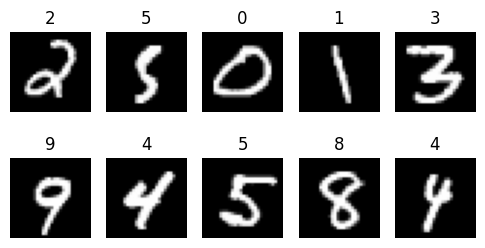

In [8]:
torch.manual_seed(7)
fig = plt.figure(figsize=(6,3))
rows, cols = 2, 5
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="grey")
  plt.title(label)
  plt.axis(False)

## 5. Convert MNIST training and test datasets into data loaders using `torch.utils.data.DataLoader`, set `batch_size=32`.
- Show what form of data dataloaders return.

In [9]:
BATCH_SIZE=32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Lenght of train dataloader: {len(train_dataloader)} items of {BATCH_SIZE}")
print(f"Lenght of test dataloader: {len(test_dataloader)} items of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7ef1a6ae5af0>, <torch.utils.data.dataloader.DataLoader object at 0x7ef1a7590e00>)
Lenght of train dataloader: 1875 items of 32
Lenght of test dataloader: 313 items of 32


In [11]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 6. Recreate `ModelV2` that we looked at in the lecture
This is the same model as from [website CNN Explainer](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG and it is capable of training on the MNIST dataset.

Write a model class.

In [12]:
class MNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [13]:
device = "cpu"

In [14]:
torch.manual_seed(7)
model = MNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
model

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Train the model you built in the previous exercise for 5 epochs on CPU and GPU and see how long it takes in each case.

In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [17]:
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Training time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [19]:
print(device)

cpu


In [20]:
def train_and_test_model():
    torch.manual_seed(7)
    train_time_start_model = timer()

    epochs = 5

    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n-------")
        train_step(data_loader=train_dataloader,
                  model=model,
                  loss_fn = loss_fn,
                  optimizer=optimizer,
                  accuracy_fn=accuracy_fn,
                  device=device)
        test_step(data_loader=test_dataloader,
                  model=model,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)

    train_time_end_model = timer()
    total_train_time_model = print_train_time(start=train_time_start_model,
                                                  end=train_time_end_model,
                                                  device=device)

In [21]:
train_and_test_model()

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.30484 | Train accuracy: 90.08%
Test loss: 0.06703 | Test accuracy: 97.76%

Epoch: 1
-------
Train loss: 0.07255 | Train accuracy: 97.73%
Test loss: 0.07210 | Test accuracy: 97.59%

Epoch: 2
-------
Train loss: 0.05597 | Train accuracy: 98.25%
Test loss: 0.04270 | Test accuracy: 98.66%

Epoch: 3
-------
Train loss: 0.04740 | Train accuracy: 98.51%
Test loss: 0.03854 | Test accuracy: 98.77%

Epoch: 4
-------
Train loss: 0.04195 | Train accuracy: 98.67%
Test loss: 0.03971 | Test accuracy: 98.70%

Training time on cpu: 179.572 seconds


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [23]:
print(device)

cuda


In [24]:
torch.manual_seed(7)
model = MNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [25]:
train_and_test_model()

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.30339 | Train accuracy: 90.18%
Test loss: 0.06164 | Test accuracy: 97.99%

Epoch: 1
-------
Train loss: 0.07205 | Train accuracy: 97.77%
Test loss: 0.07106 | Test accuracy: 97.53%

Epoch: 2
-------
Train loss: 0.05525 | Train accuracy: 98.28%
Test loss: 0.03901 | Test accuracy: 98.70%

Epoch: 3
-------
Train loss: 0.04645 | Train accuracy: 98.53%
Test loss: 0.03647 | Test accuracy: 98.77%

Epoch: 4
-------
Train loss: 0.04073 | Train accuracy: 98.71%
Test loss: 0.04204 | Test accuracy: 98.54%

Training time on cuda: 59.443 seconds


## 8. Make predictions using your trained model and visualize at least 5 of them, comparing the prediction to the target label.

In [26]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

In [27]:
random.seed(7)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape} \nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28]) 
Test sample label: 0 (0 - zero)


In [28]:
pred_probs= make_predictions(model=model, data=test_samples)

In [29]:
pred_probs[:2]

tensor([[1.0000e+00, 3.1312e-14, 2.4670e-08, 2.1233e-11, 3.3600e-13, 5.0930e-11,
         5.0696e-08, 1.3499e-10, 5.3744e-08, 1.3236e-07],
        [1.7885e-07, 1.8586e-09, 1.8717e-07, 8.2750e-07, 3.0223e-07, 3.8315e-06,
         9.9999e-01, 2.9860e-10, 1.4218e-06, 8.0902e-10]])

In [30]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([0, 6, 1, 5, 7, 6, 4, 1, 3])

In [31]:
print(test_labels)
print(pred_classes.tolist())

[0, 6, 1, 5, 7, 6, 4, 1, 3]
[0, 6, 1, 5, 7, 6, 4, 1, 3]


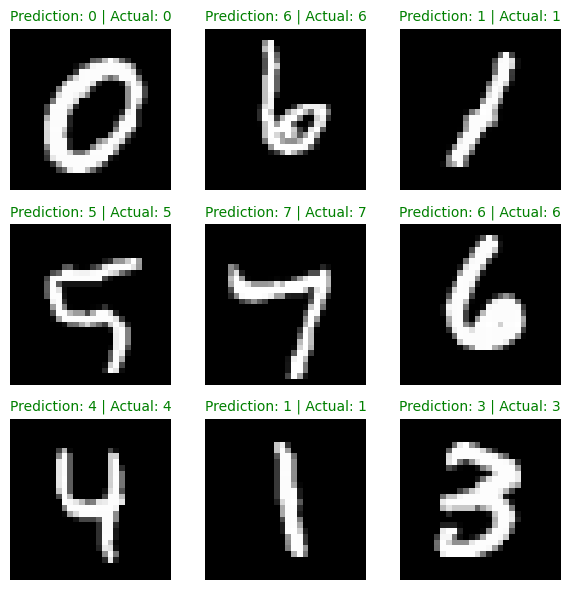

In [32]:
plt.figure(figsize=(6, 6))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = pred_classes[i]
    truth_label = test_labels[i]
    title_text = f"Prediction: {pred_label} | Actual: {truth_label}"

    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")
    plt.axis(False)
plt.tight_layout();

## 9. Construct a confusion matrix by comparing your model's predictions to the true labels.

In [33]:
y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Predicting"):
    X, y = X.to(device), y.to(device)
    y_logit = model(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

Predicting:   0%|          | 0/313 [00:00<?, ?it/s]

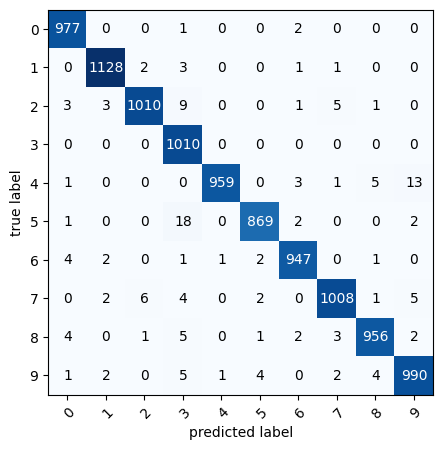

In [34]:
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=np.arange(0, 10, 1).tolist(),
    figsize=(8, 5)
);

Model showed very good result.

## 10. Output at least 9 examples where the model is wrong, along with what the image label should have been.
* After visualizing these predictions, do you think this is more of a model error or a data error?
* Could the model do better, or are the data labels too close together that even a human cannot clearly distinguish which number is which?

In [35]:
wrong_idx = torch.where(y_pred_tensor != test_data.targets)[0]
len(wrong_idx)

146

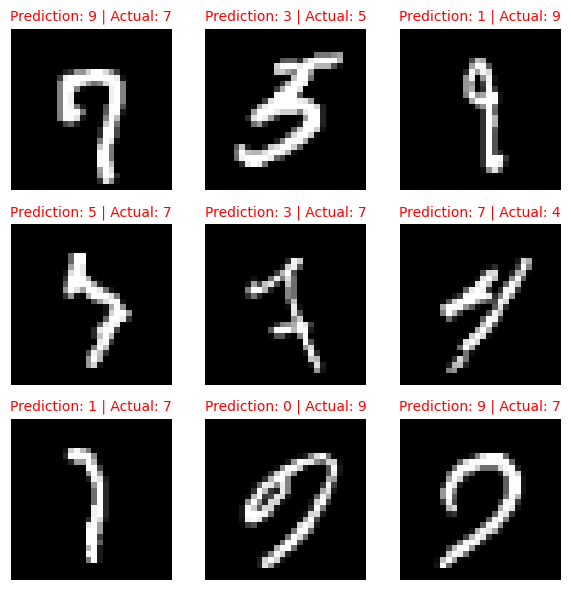

In [36]:
random.seed(7)

fig = plt.figure(figsize=(6, 6))
rows, cols = 3, 3
for i, idx in enumerate(random.sample(list(wrong_idx), k=rows*cols)):
    sample, label = test_data.data[idx], test_data.targets[idx]
    fig.add_subplot(rows, cols, i+1)
    plt.imshow(sample.squeeze(), cmap='gray')
    pred_label = y_pred_tensor[idx]
    title_text = f"Prediction: {pred_label} | Actual: {label}"
    plt.title(title_text, fontsize=10, c='r')

    plt.axis(False)
plt.tight_layout()
plt.show()

We can see that misclassified examples are really hard to identify even for people.

## 11. Create a random tensor of the form `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with different hyperparameter settings (you can choose any settings), what do you notice if the `kernel_size` parameter is increased or decreased?

In [37]:
torch.manual_seed(7)

test_image = torch.randn(size=(1, 3, 64, 64))
test_image.shape

torch.Size([1, 3, 64, 64])

In [38]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=6,
                       kernel_size=3,
                       padding=0)

conv_layer(test_image).shape

torch.Size([1, 6, 62, 62])

In [39]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=2,
                       padding=1)

conv_layer(test_image).shape

torch.Size([1, 10, 65, 65])

In [40]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=1,
                       padding=0)

conv_layer(test_image).shape

torch.Size([1, 10, 64, 64])

In [41]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=5,
                       padding=0)

conv_layer(test_image).shape

torch.Size([1, 10, 60, 60])

for `padding = 0`:

64 → 62 if kernel_size=3

64 → 64 if kernel_size=1

64 → 60 if kernel_size=5

**Increasing** `kernel_size` allows the convolution to capture a larger spatial context but reduces the output feature map size and increases the number of parameters.    
**Decreasing** `kernel_size` preserves more spatial detail, uses fewer parameters, and is computationally more efficient.

In [42]:
for k in [1, 3, 5]:
    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k)
    params = sum(p.numel() for p in conv.parameters())
    print(f"Kernel {k}x{k}: {params} parameters")

Kernel 1x1: 32 parameters
Kernel 3x3: 224 parameters
Kernel 5x5: 608 parameters


larger kernel size = more memory + more computation